In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\HomePC\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_exploded = df.explode('job_skills')

In [5]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

type(skills_count)

pandas.Series

In [6]:
df_skills_count = skills_count.reset_index(name='skills_count')

df_skills_count = df_skills_count.sort_values(by='skills_count', ascending=False).reset_index(drop=True)

df_skills_count

,job_title_short,job_skills,skills_count
0,Data Scientist,python,113711
1,Data Engineer,sql,113130
2,Data Engineer,python,108022
3,Data Analyst,sql,92428
4,Data Scientist,sql,78982
...,...,...,...
2251,Data Analyst,chainer,1
2252,Cloud Engineer,wrike,1
2253,Cloud Engineer,theano,1
2254,Business Analyst,chainer,1


In [7]:
job_title = 'Data Engineer'
top_skills = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills) 

df_skill_final

,job_title_short,job_skills,skills_count
1,Data Engineer,sql,113130
2,Data Engineer,python,108022
6,Data Engineer,aws,62049
7,Data Engineer,azure,60674
10,Data Engineer,spark,53656
13,Data Engineer,java,35559
17,Data Engineer,kafka,29073
19,Data Engineer,hadoop,28815
20,Data Engineer,scala,28716
23,Data Engineer,databricks,27477


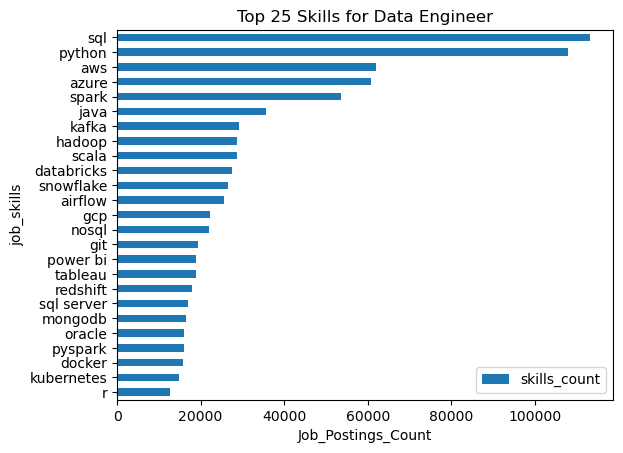

In [ ]:
job_title = 'Data Engineer'
top_skills = 25

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills) 

df_skill_final.plot(x='job_skills', y='skills_count', kind='barh')
plt.xlabel('Job_Postings_Count')
plt.title(f'Top {top_skills} Skills for {job_title}')
plt.gca().invert_yaxis()
plt.show()

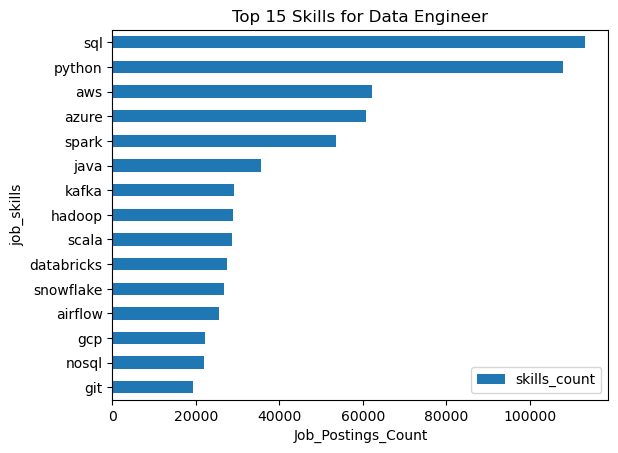

In [13]:
job_title = 'Data Engineer'
top_skills = 15

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills) 

df_skill_final.plot(x='job_skills', y='skills_count', kind='barh')
plt.xlabel('Job_Postings_Count')
plt.title(f'Top {top_skills} Skills for {job_title}')
plt.gca().invert_yaxis()
plt.legend().set_visible(True)
plt.show()

In [9]:
# Summary conclusion from the barh plot (top skills for Data Engineer)
conclusion = (
    f"Top {top_skills} skills for {job_title}: "
    + ", ".join(df_skill_final['job_skills'].astype(str).tolist())
    + ".\nKey takeaways: SQL and Python are dominant; cloud platforms (AWS, Azure) are highly requested; "
    + "big-data & streaming tools (Spark, Kafka, Hadoop, Databricks, Scala, Java) are common — focus on SQL/Python, cloud, and distributed/streaming systems."
)

print(conclusion)

Top 25 skills for Data Engineer: sql, python, aws, azure, spark, java, kafka, hadoop, scala, databricks, snowflake, airflow, gcp, nosql, git, power bi, tableau, redshift, sql server, mongodb, oracle, pyspark, docker, kubernetes, r.
Key takeaways: SQL and Python are dominant; cloud platforms (AWS, Azure) are highly requested; big-data & streaming tools (Spark, Kafka, Hadoop, Databricks, Scala, Java) are common — focus on SQL/Python, cloud, and distributed/streaming systems.
